<a href="https://colab.research.google.com/github/ashwin-inquisitor/Machine-Learning/blob/main/vanet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Installing dependencies

In [ ]:
!pip install -U "flwr[simulation]" torch torchvision scikit-learn pandas numpy matplotlib openpyxl

In [ ]:

!pip uninstall -y torch torchvision torchaudio flwr ray

!pip install torch==2.3.1
!pip install torchvision==0.11
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install openpyxl
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install flwr==1.13.1
!pip install ray==2.31.0

Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
Found existing installation: torchvision 0.18.1
Uninstalling torchvision-0.18.1:
  Successfully uninstalled torchvision-0.18.1
Found existing installation: flwr 1.13.1
Uninstalling flwr-1.13.1:
  Successfully uninstalled flwr-1.13.1
Found existing installation: ray 2.31.0
Uninstalling ray-2.31.0:
  Successfully uninstalled ray-2.31.0
  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.28 requires torchvision, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.

  Using cached ray-2.31.0-cp312-cp312-manylinux2014_x86_64.whl.metadata (13 kB)
Using cached ray-2.31.0-cp312-cp312-manylinux2014_x86_64.whl (66.7 MB)


In [ ]:
import sys

!{sys.executable} -m pip uninstall -y protobuf grpcio grpcio-status \
    tensorflow tensorflow-estimator tensorflow-io tensorflow-metadata \
    tb-nightly h5py keras-nightly libclang wrapt astunparse gast \
    termcolor flatbuffers opt-einsum google-pasta

!{sys.executable} -m pip install flwr==1.8.0 --force-reinstall

print('Restarting runtime — after it restarts, run the NEXT cell.')
get_ipython().kernel.do_shutdown(restart=True)

Found existing installation: protobuf 4.25.9
Uninstalling protobuf-4.25.9:
  Successfully uninstalled protobuf-4.25.9
Found existing installation: grpcio 1.64.3
Uninstalling grpcio-1.64.3:
  Successfully uninstalled grpcio-1.64.3
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-metadata 1.21.0
Uninstalling tensorflow-metadata-1.21.0:
  Successfully uninstalled tensorflow-metadata-1.21.0
Found existing installation: h5py 3.16.0
Uninstalling h5py-3.16.0:
  Successfully uninstalled h5py-3.16.0
Found existing installation: libclang 18.1.1
Uninstalling libclang-18.1.1:
  Successfully uninstalled libclang-18.1.1
Found existing installation: wrapt 2.2.2
Uninstalling wrapt-2.2.2:
  Successfully uninstalled wrapt-2.2.2
Found existing installation: astunparse 1.6.3
Uninstalling astunparse-1.6.3:
  Successfully uninstalled astunparse-1.6.3
Found existing installation: gast 0.7.0
Unin

{'status': 'ok', 'restart': True}

Imports

In [ ]:
import flwr as fl
import os

os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch

torch.set_num_threads(1)

import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, roc_curve, auc,
                             precision_recall_curve, f1_score,
                             classification_report)
from flwr.common import Metrics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


load and encode dataset

In [ ]:
# Read the Excel file into a pandas DataFrame
df = pd.read_excel("/content/10000.xlsx")

# Print the number of rows and columns in the dataset
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ── Encode categorical features to ordinal numeric values ───────────
#    Higher value = more hazardous condition

# Dictionary for converting weather conditions into numerical values
# Larger numbers represent more hazardous weather conditions
WEATHER_MAP = {
    'Fine no high winds'    : 0,   # Best weather condition
    'Fine + high winds'     : 1,   # Wind increases risk
    'Raining no high winds' : 2,   # Rain makes roads slippery
    'Raining + high winds'  : 3,   # Rain + wind = higher danger
    'Fog or mist'           : 4,   # Poor visibility
    'Snowing no high winds' : 5,   # Highest hazard
    'Other'                 : 2,   # Moderate hazard
    'Unknown'               : 1,   # Unknown condition assigned low risk
}
# Dictionary for converting road types into numerical values
ROAD_TYPE_MAP = {
    'Dual carriageway'  : 0,   # Safer due to divided lanes
    'Single carriageway': 1,   # Slightly more dangerous
    'Roundabout'        : 2,   # Moderate risk
    'One way street'    : 2,   # Similar risk
    'Slip road'         : 3,   # Higher merging risk
    'Unknown'           : 1,   # Default value
}
# Dictionary for converting road surface conditions into numerical values
SURFACE_MAP = {
    'Dry'         : 0,   # Safest surface
    'Wet or damp' : 1,   # Slippery
    'Frost or ice': 2,   # More dangerous
    'Snow'        : 3,   # Highest danger
}
# Dictionary for converting lighting conditions into numerical values
LIGHT_MAP = {
    'Daylight'                    : 0,   # Best visibility
    'Darkness - lights lit'       : 1,   # Street lights available
    'Darkness - lighting unknown' : 2,   # Unknown lighting
    'Darkness - lights unlit'     : 3,   # Worst visibility
}

# Replace weather categories with numerical values
df['weather_enc'] = df['Weather_Conditions'].map(WEATHER_MAP)

# Replace road type categories with numerical values
df['road_enc'] = df['Road_Type'].map(ROAD_TYPE_MAP)

# Replace road surface categories with numerical values
df['surface_enc'] = df['Road_Surface_Conditions'].map(SURFACE_MAP)

# Replace light condition categories with numerical values
df['light_enc'] = df['Light_Conditions'].map(LIGHT_MAP)

# ── Label: Fatal or Serious = 1,  Slight = 0 ───────────────────────
# Create a binary target variable (Label)
# Fatal and Serious accidents are labeled as 1 (High Risk)
# Slight accidents are labeled as 0 (Low Risk)
df['Label'] = df['Accident_Severity'].apply(
    lambda x: 1 if x in ['Fatal', 'Serious'] else 0
)
# Display how many accidents belong to the high-risk class
print(f"Label distribution — High Risk: {df['Label'].sum()} / {len(df)}")

# ── Sort by district then date so sliding windows capture real      ──
# ── geographic-temporal patterns instead of random accident order   ──
#
# WHY: LSTM sequences assume temporal dependency between consecutive
# rows. Without sorting, row[i] and row[i+1] are unrelated accidents
# from different locations. After sorting, a window of 10 rows = 10
# accidents in the same district over time → real temporal signal.
#
# If 'Date' column is absent or named differently, sorting falls back
# to district-only, which still groups accidents geographically.

# Name of the district column
DISTRICT_COL = 'Local_Authority_(District)'

# Name of the date column
DATE_COL = 'Date'

# Create an empty list to store columns used for sorting
sort_cols = []
# Check whether district column exists
if DISTRICT_COL in df.columns:

    # Add district column for sorting
    sort_cols.append(DISTRICT_COL)

    # Inform the user
    print(f"✅ Sorting by district column: '{DISTRICT_COL}'")

else:

    # Warning if district column is missing
    print(f"⚠️ District column '{DISTRICT_COL}' not found — skipping district sort")

# Check whether date column exists
if DATE_COL in df.columns:

    # Convert the Date column into datetime format
    df[DATE_COL] = pd.to_datetime(
        df[DATE_COL],
        dayfirst=True,
        errors='coerce'
    )

    # Add date column for sorting
    sort_cols.append(DATE_COL)

    # Inform the user
    print(f"✅ Sorting by date column: '{DATE_COL}'")

else:

    # Warning if date column is absent
    print(f"⚠️ Date column '{DATE_COL}' not found — skipping date sort")

# If at least one sorting column exists
if sort_cols:

    # Sort the DataFrame by district and date
    df = df.sort_values(sort_cols).reset_index(drop=True)

    # Display sorting information
    print(f"✅ DataFrame sorted by: {sort_cols}")

else:

    # Warning if no sorting columns are available
    print("⚠️ No sort columns found — sequences will use original row order")

Dataset loaded: 10001 rows, 34 columns
Label distribution — High Risk: 1026 / 10001
✅ Sorting by district column: 'Local_Authority_(District)'
✅ Sorting by date column: 'Date'
✅ DataFrame sorted by: ['Local_Authority_(District)', 'Date']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Accient risk score formula

In [ ]:
#  Risk Score (0–100) =
#    (Speed_limit / 60) × 30   — speed         [priority 1]
#    (weather_enc / 5)  × 20   — weather        [priority 2]
#    (surface_enc / 3)  × 20   — road surface   [priority 3]
#    (light_enc   / 3)  × 15   — lighting       [priority 4]
#    (Vehicles    / 5)  × 10   — traffic density [priority 5]
#    (road_enc    / 3)  ×  5   — road type      [priority 6]

# Function to calculate the overall risk score of an accident
def compute_risk_score(row_dict):

    # Return the weighted sum of all risk factors
    return (

        # Speed contributes a maximum of 30 points
        (row_dict['Speed_limit'] / 60) * 30 +

        # Weather contributes a maximum of 20 points
        (row_dict['weather_enc'] / 5) * 20 +

        # Road surface contributes a maximum of 20 points
        (row_dict['surface_enc'] / 3) * 20 +

        # Lighting contributes a maximum of 15 points
        (row_dict['light_enc'] / 3) * 15 +

        # Number of vehicles contributes a maximum of 10 points
        (row_dict['Number_of_Vehicles'] / 5) * 10 +

        # Road type contributes a maximum of 5 points
        (row_dict['road_enc'] / 3) * 5
    )

# Function to classify the numerical risk score into categories
def risk_level(score):

    # Score less than 20 indicates low risk
    if score < 20:
        return "Low"

    # Score between 20 and 39.99 indicates moderate risk
    elif score < 40:
        return "Moderate"

    # Score between 40 and 59.99 indicates high risk
    elif score < 60:
        return "High"

    # Score 60 or above indicates critical risk
    else:
        return "Critical"

Feature selection and normalization

In [ ]:
# List of features that will be used to train the model
FEATURES = [

    # Speed limit of the road (20, 30, 40, 50, or 60 mph)
    'Speed_limit',

    # Encoded weather condition (0 = fine, 5 = snow)
    'weather_enc',

    # Encoded road surface condition (0 = dry, 3 = snow/ice)
    'surface_enc',

    # Encoded lighting condition (0 = daylight, 3 = dark without lights)
    'light_enc',

    # Number of vehicles involved in the accident
    'Number_of_Vehicles',

    # Encoded road type (0 = dual carriageway, 3 = slip road)
    'road_enc',
]

# Extract only the selected feature columns from the DataFrame
X = df[FEATURES].values
# Extract the target labels (0 = Slight, 1 = Fatal/Serious)
y = df['Label'].values

# Create a StandardScaler object for feature normalization
scaler = StandardScaler()
# Compute the mean and standard deviation of each feature,
# then transform the data to have mean 0 and standard deviation 1
X = scaler.fit_transform(X)


# Calculate balanced class weights to compensate for class imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=y
)
# Convert the ratio of positive-to-negative class weights into a PyTorch tensor
pos_weight = torch.tensor(
    [class_weights[1] / class_weights[0]],
    dtype=torch.float32
)
# Display the calculated class weights
print(f"Class weights → 0: {class_weights[0]:.2f}, 1: {class_weights[1]:.2f}")

Class weights → 0: 0.56, 1: 4.87


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Sequence creation

In [ ]:
# Number of consecutive accidents in one input sequence
SEQ_LEN = 10

# Function to create sliding-window sequences for the LSTM
def create_sequences(X, y, seq_len, district_labels=None):
    """
    Build sliding-window sequences from feature matrix X and labels y.

    district_labels (optional): array of district strings, same length as X.
      When provided, sequences are NOT allowed to cross district boundaries.
      A window that starts in district A must stay entirely in district A.
      This ensures each sequence represents real geographic-temporal context
      rather than stitching together unrelated accidents from different areas.

    Without district_labels the function behaves exactly as before (fallback).
    """
    # Store input sequences
    Xs = []
    # Store output labels
    ys = []
    # Move the sliding window through the dataset
    for i in range(len(X) - seq_len):
        # Check whether district information is available
        if district_labels is not None:
            # Extract the districts covered by the current window
            window_districts = district_labels[i : i + seq_len + 1]
            # If more than one district exists, reject this sequence
            if len(set(window_districts)) > 1:
                # Skip sequences that cross district boundaries
                continue
        # Save the current sequence
        Xs.append(X[i : i + seq_len])
        # Save the label of the next accident
        ys.append(y[i + seq_len])
    # Convert lists into NumPy arrays
    return np.array(Xs), np.array(ys)


# Check if district information is available
if DISTRICT_COL in df.columns:
    # Get district names
    district_labels = df[DISTRICT_COL].values
    # Create sequences without crossing district boundaries
    X_seq, y_seq = create_sequences(
        X,
        y,
        SEQ_LEN,
        district_labels=district_labels
    )
    # Display the number and dimensions of generated sequences
    print(f"Sequences created (district-aware) : {X_seq.shape}")
else:

    # Create sequences normally
    X_seq, y_seq = create_sequences(X, y, SEQ_LEN)

    # Display sequence shape
    print(f"Sequences created (fallback) : {X_seq.shape}")

# Split the sequences into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)
# Display the size of the training and testing datasets
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Sequences created (district-aware) : (9801, 10, 6)
Train : (7840, 10, 6) | Test : (1961, 10, 6)


CLustering

In [ ]:
NUM_CLIENTS = 9   # 3 clusters × 3 clients each
N_CLUSTERS  = 3


def dirichlet_split(X, y, num_clients, alpha=0.5, seed=42):
    """
    Splits data non-IID across clients using Dirichlet distribution.
    alpha → 0   : extreme non-IID (each client gets mostly one class)
    alpha → inf : IID (uniform distribution across clients)
    """
    np.random.seed(seed)
    num_classes = len(np.unique(y))
    client_idxs = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        class_idx = np.where(y == c)[0]
        np.random.shuffle(class_idx)

        proportions     = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions     = (proportions * len(class_idx)).astype(int)
        # Fix rounding so all samples are assigned
        proportions[-1] = len(class_idx) - proportions[:-1].sum()

        start = 0
        for cid, count in enumerate(proportions):
            client_idxs[cid].extend(class_idx[start : start + count])
            start += count

    result = []
    for idxs in client_idxs:
        idxs = np.array(idxs)
        if len(idxs) == 0:
            idxs = np.array([0])   # safety fallback
        result.append((X[idxs], y[idxs]))

    return result


def elect_cluster_heads(client_datasets, cluster_map):
    """
    Elects one cluster-head per cluster based on:
      - Data size    (weight 0.6) — more data = more representative
      - Label balance (weight 0.4) — balanced client avoids biased aggregation
    """
    n_clusters    = max(cluster_map.values()) + 1
    cluster_heads = {}

    print("\n── Cluster-Head Election ────────────────────────────────────")
    for cluster_id in range(n_clusters):
        members    = [cid for cid, c in cluster_map.items()
                      if c == cluster_id]
        best_cid   = None
        best_score = -1

        cluster_name = {0: 'Urban', 1: 'Rural', 2: 'Motorway'}[cluster_id]
        print(f"\n  Cluster {cluster_id} ({cluster_name}):")

        for cid in members:
            X_c, y_c = client_datasets[cid]
            if len(y_c) == 0:
                continue

            n_samples = len(y_c)
            # balance: 1 = perfectly balanced, 0 = all one class
            balance   = 1 - abs(float(y_c.mean()) - 0.5) * 2
            score     = 0.6 * (n_samples / 500.0) + 0.4 * balance

            serious_rate = float(y_c.mean()) * 100
            print(f"    Client {cid}: samples={n_samples:4d}, "
                  f"serious={serious_rate:.1f}%, "
                  f"balance={balance:.2f}, score={score:.3f}")

            if score > best_score:
                best_score = score
                best_cid   = cid

        cluster_heads[cluster_id] = best_cid
        print(f"    → Elected: Client {best_cid} as cluster-head")

    print("\n── Cluster-Head Summary ─────────────────────────────────────")
    for cid_cluster, head in cluster_heads.items():
        name = {0: 'Urban', 1: 'Rural', 2: 'Motorway'}[cid_cluster]
        print(f"  Cluster {cid_cluster} ({name}) → Head: Client {head}")
    print("─────────────────────────────────────────────────────────────\n")

    return cluster_heads


Run Split + election

In [ ]:
client_datasets = dirichlet_split(
    X_seq, y_seq,
    num_clients=NUM_CLIENTS,
    alpha=0.5
)
print(f"\nClient dataset sizes: "
      f"{[len(cd[1]) for cd in client_datasets]}")

# Cluster map: clients 0-2 → urban (0)
#              clients 3-5 → rural  (1)
#              clients 6-8 → motorway (2)
cluster_map = {
    0: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
}

cluster_heads = elect_cluster_heads(client_datasets, cluster_map)

# Per-cluster accuracy tracking (Fix [14] lite version)
cluster_accuracies = {0: [], 1: [], 2: []}


Client dataset sizes: [374, 2655, 1140, 1705, 100, 357, 3297, 11, 162]

── Cluster-Head Election ────────────────────────────────────

  Cluster 0 (Urban):
    Client 0: samples= 374, serious=96.8%, balance=0.06, score=0.474
    Client 1: samples=2655, serious=0.0%, balance=0.00, score=3.186
    Client 2: samples=1140, serious=4.9%, balance=0.10, score=1.407
    → Elected: Client 1 as cluster-head

  Cluster 1 (Rural):
    Client 3: samples=1705, serious=1.8%, balance=0.04, score=2.060
    Client 4: samples= 100, serious=67.0%, balance=0.66, score=0.384
    Client 5: samples= 357, serious=22.4%, balance=0.45, score=0.608
    → Elected: Client 3 as cluster-head

  Cluster 2 (Motorway):
    Client 6: samples=3297, serious=7.5%, balance=0.15, score=4.017
    Client 7: samples=  11, serious=63.6%, balance=0.73, score=0.304
    Client 8: samples= 162, serious=97.5%, balance=0.05, score=0.214
    → Elected: Client 6 as cluster-head

── Cluster-Head Summary ──────────────────────────────────

Dataloader helper

In [ ]:
def make_loader(X_arr, y_arr, batch_size=8, shuffle=True):
    X_t = torch.tensor(X_arr, dtype=torch.float32)   # (N, 10, 6)
    y_t = torch.tensor(y_arr, dtype=torch.float32).view(-1, 1)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=False)

In [ ]:
device = torch.device("cpu")

Bi-LSTM model with hidden-state exposure for RASC importance analysisLstm model

In [ ]:
class LSTMModel(nn.Module):
    """
    Bi-directional LSTM for accident risk prediction.

    Architecture change from vanilla LSTM:
      - bidirectional=True: forward + backward pass over each sequence
      - hidden_size doubled internally by PyTorch for bi-directional,
        so fc input is hidden_dim * 2
      - return_hidden flag: when True, forward() returns (logit, h_last)
        so the RASC importance analyzer can tap hidden states without
        a separate backward pass.

    RASC integration:
      During compression, importance scores are computed as:
        I_i = |∂Risk/∂h_i|  for each hidden-state neuron h_i
      This requires h_last to be exposed — hence return_hidden.
    """

    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super(LSTMModel, self).__init__()

        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.bn = nn.LayerNorm(hidden_dim * 2)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, return_hidden=False):
        lstm_out, (h_n, _) = self.lstm(x)

        # Last time-step output
        out = lstm_out[:, -1, :]
        out = self.bn(out)
        out = self.drop(out)

        # Raw logit (no sigmoid)
        logit = self.fc(out)

        if return_hidden:
            # Last forward + backward hidden states
            h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)
            return logit, h_last

        return logit


# ──────────────────────────────────────────────────────────────────────────────
# RASC Importance Analyzer
# ──────────────────────────────────────────────────────────────────────────────
def compute_importance_scores(model, x_batch):
    """
    Computes per-neuron importance scores

        I_i = |∂Risk/∂h_i|

    using automatic differentiation over the Bi-LSTM hidden states.

    Args:
        model   : LSTMModel
        x_batch : Tensor of shape (batch, seq_len, features)

    Returns:
        importance : NumPy array of shape (hidden_dim * 2,)
    """

    # Move model to selected device
    model.to(device)
    model.eval()

    # Move batch to device
    x_batch = x_batch.to(device)
    x_batch = x_batch.detach().requires_grad_(False)

    with torch.enable_grad():

        # Forward pass
        logit, h_last = model(x_batch, return_hidden=True)

        # Retain gradient of hidden state
        h_last.retain_grad()

        # Mean risk probability
        risk = torch.sigmoid(logit).mean()

        # Backpropagate only through hidden state
        risk.backward(retain_graph=False)

        if h_last.grad is not None:

            # Mean absolute gradient across batch
            importance = (
                h_last.grad
                .abs()
                .mean(dim=0)
                .detach()
                .cpu()
                .numpy()
            )

        else:
            importance = np.ones(
                model.hidden_dim * 2,
                dtype=np.float32
            )

    model.train()

    return importance

Train and Test Functions

In [ ]:
MU = 0.01


def train(model, trainloader, global_params, epochs=5):
    """
    FedProx loss = BCEWithLogitsLoss(logit, label)
                 + (mu/2) × ||w_local - w_global||²

    BCEWithLogitsLoss = sigmoid + BCE in one numerically stable op.
    Model outputs raw logits — sigmoid is NOT applied inside model.
    """
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    model.to(device)
    model.train()

    # Ensure global parameters are on the same device
    global_params = [p.to(device) for p in global_params]

    epoch_loss = 0.0

    for _ in range(epochs):
        for x, y_batch in trainloader:

            # Move data to device
            x = x.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(x)                    # raw logits
            loss = criterion(logits, y_batch)    # sigmoid applied inside loss

            # ── FedProx proximal term ──────────────────────────────
            prox = 0.0
            for local_w, global_w in zip(model.parameters(), global_params):
                prox += (local_w - global_w).norm(2) ** 2
            loss += (MU / 2) * prox
            # ───────────────────────────────────────────────────────

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()

    return epoch_loss / (len(trainloader) * epochs)


def test(model, testloader):
    model.to(device)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y_batch in testloader:

            # Move data to device
            x = x.to(device)
            y_batch = y_batch.to(device)

            # Sigmoid applied during inference
            probs = torch.sigmoid(model(x))
            preds = (probs > 0.5).float()

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return accuracy_score(y_true, y_pred)

Compression pipeline

In [ ]:
RASC_ALPHA  = 0.5    # weight for semantic importance score S_i
RASC_BETA   = 0.3    # weight for risk factor RF
RASC_GAMMA  = 0.2    # weight for mobility factor MF

# Quantization bit-widths mapped to QSGD quantization levels
# R > 0.8  → 16-bit  (256 levels)
# 0.4–0.8  →  8-bit  (128 levels)
# 0.1–0.4  →  4-bit  ( 16 levels)
# ≤ 0.1    →  drop   (  0 / discard)
RASC_THRESHOLDS = [0.8, 0.4, 0.1]
RASC_LEVELS     = {
    'critical'    : 256,   # 16-bit equivalent
    'important'   :  128,   # 8-bit equivalent
    'minor'       :  16,   # 4-bit equivalent
    'discard'     :   0,
}

# Mobility speed reference: km/h above which we consider vehicle "fast"
SPEED_REF = 60.0


# ── RASC Scoring Engine ───────────────────────────────────────────────────────
def rasc_score(params, importance_vec, risk_prob, speed):
    """
    Computes per-element final RASC importance score R_i for every gradient.

    R_i = α × S_i  +  β × RF  +  γ × MF

    where:
      S_i = I_i × |g_i|   (semantic score: importance × gradient magnitude)
      RF  = β × P(accident) (risk factor from Bi-LSTM prediction)
      MF  = γ × f(speed)  (mobility factor: higher speed → stronger compression)
              f(speed) = min(speed / SPEED_REF, 1.0)

    Args:
        params        : list of np.ndarray (model parameter gradients)
        importance_vec: np.ndarray (hidden_dim*2,) from compute_importance_scores
        risk_prob     : float, P(accident) from current Bi-LSTM prediction
        speed         : float, current vehicle speed estimate (km/h)

    Returns:
        scores: list of np.ndarray, same shapes as params,
                each element in [0, 1] (after min-max normalization)
    """
    # ── Risk Factor Module ──────────────────────────────────────────────
    # RF is a scalar applied uniformly across all gradients.
    # Higher accident probability → higher RF → more gradients kept at high precision.
    RF = float(np.clip(risk_prob, 0.0, 1.0))

    # ── Mobility Factor Module ──────────────────────────────────────────
    # High-speed vehicles have shorter communication windows → stronger compression.
    # MF ∈ [0, 1]; higher speed → higher MF → lower final R_i → more compression.
    # Note: MF *reduces* R_i (it competes with S_i), so fast vehicles transmit less.
    MF = float(np.clip(speed / SPEED_REF, 0.0, 1.0))

    scores = []
    for p in params:
        flat = p.flatten().astype(np.float32)

        # ── Semantic Score S_i = I_i × |g_i| ───────────────────────────
        # importance_vec covers hidden-state neurons; we broadcast it to
        # full gradient shapes by using its mean as a scalar proxy when
        # shapes don't match (e.g., fc layer weights vs LSTM weights).
        if len(flat) == len(importance_vec):
            I = importance_vec
        else:
            I = np.full(len(flat), importance_vec.mean(), dtype=np.float32)

        S = I * np.abs(flat)          # element-wise semantic score

        # Normalize S to [0, 1]
        s_max = S.max()
        if s_max > 0:
            S = S / s_max

        # ── Final RASC Score R_i ────────────────────────────────────────
        R = RASC_ALPHA * S + RASC_BETA * RF - RASC_GAMMA * MF
        R = np.clip(R, 0.0, 1.0)

        scores.append(R.reshape(p.shape))

    return scores


# ── Risk-Aware Adaptive Quantizer ─────────────────────────────────────────────
def _qsgd_quantize(arr, n_levels):
    """QSGD quantization at a given number of levels."""
    if n_levels == 0:
        return None   # discard signal

    arr16  = arr.astype(np.float16)
    norm   = float(np.linalg.norm(arr16))
    if norm == 0:
        return {
            'signs' : np.zeros(arr16.shape, dtype=np.int8),
            'levels': np.zeros(arr16.shape, dtype=np.uint8),
            'scale' : np.float32(0),
            'shape' : arr.shape,
            'n_lvl' : n_levels,
        }

    normalized = arr16 / norm
    scaled     = np.abs(normalized) * n_levels
    floored    = np.floor(scaled).astype(np.uint8)
    prob       = scaled - floored
    rounded    = floored + (np.random.rand(*arr16.shape) < prob).astype(np.uint8)
    signs      = np.sign(arr16).astype(np.int8)

    return {
        'signs' : signs,
        'levels': rounded,
        'scale' : np.float32(norm),
        'shape' : arr.shape,
        'n_lvl' : n_levels,
    }


def compress(params, error_buffer, importance_vec=None,
             risk_prob=0.5, speed=30.0):
    """
    RASC compression replacing the original Top-K + Float16 + QSGD stack.

    Per-element flow:
      1. Error compensation:   g̃_i = g_i + e_{t-1}
      2. RASC scoring:         R_i  = αS_i + βRF - γMF
      3. Tier assignment:      R_i → {critical, important, minor, discard}
      4. Adaptive quantization: QSGD at tier-specific bit-width
      5. Error feedback:        e_t = g̃_i - C(g̃_i)

    Args:
        params        : list of np.ndarray (model weights / gradients)
        error_buffer  : list of np.ndarray (per-param residual from last round)
        importance_vec: np.ndarray or None; if None, falls back to magnitude-only
        risk_prob     : float, P(accident) ∈ [0, 1]
        speed         : float, vehicle speed km/h

    Returns:
        compressed_arrays: list of np.ndarray, containing flattened representation
                           of compressed parameters.
    """
    if importance_vec is None:
        # Fallback: flat importance (equivalent to pure Top-K behavior)
        importance_vec = np.ones(64 * 2, dtype=np.float32)

    # Compute RASC scores for all params
    rasc_scores = rasc_score(params, importance_vec, risk_prob, speed)

    compressed_arrays = [] # This will be a flat list of np.ndarray
    for i, (p, score_map) in enumerate(zip(params, rasc_scores)):
        # ── Step 1: Error Compensation ──────────────────────────────────
        g_corrected = p + error_buffer[i]

        # ── Step 2: Per-element tier assignment based on mean R_i ───────
        # We use the mean score of the parameter tensor to decide its tier.
        # (Element-wise tiering would require variable-length encoding —
        #  beyond scope; tensor-level tiering is standard in practice.)
        r_mean = float(score_map.mean())

        if r_mean > RASC_THRESHOLDS[0]:
            tier_name = 'critical'
        elif r_mean > RASC_THRESHOLDS[1]:
            tier_name = 'important'
        elif r_mean > RASC_THRESHOLDS[2]:
            tier_name = 'minor'
        else:
            tier_name = 'discard'
        n_levels = RASC_LEVELS[tier_name]

        # Log the real tier assignment for this tensor (used later to plot
        # the actual compression breakdown instead of hardcoded numbers).

        # ── Step 3: Adaptive Quantization ───────────────────────────────
        quantized = _qsgd_quantize(g_corrected, n_levels)

        # ── Step 4: Error Feedback ───────────────────────────────────────
        if quantized is None:
            # Discarded: accumulate full gradient into error buffer
            error_buffer[i] = g_corrected
            # Send a zero placeholder so shape is preserved in aggregation
            compressed_arrays.extend([
                np.zeros(p.shape, dtype=np.int8), # signs
                np.zeros(p.shape, dtype=np.uint8), # levels
                np.array(0.0, dtype=np.float32), # scale as 0-D array
                np.array(p.shape, dtype=np.int32), # shape as 1-D array
                np.array(1, dtype=np.int32) # n_lvl as 0-D array (send 1 to avoid division by zero in decompress)
            ])
        else:
            # Reconstruct what was sent to compute residual
            reconstructed = (
                quantized['signs'].astype(np.float32)
                * (quantized['levels'].astype(np.float32) / max(quantized['n_lvl'], 1))
                * float(quantized['scale'])
            ).reshape(p.shape)
            error_buffer[i] = g_corrected - reconstructed
            compressed_arrays.extend([
                quantized['signs'],
                quantized['levels'],
                np.array(quantized['scale'], dtype=np.float32),
                np.array(quantized['shape'], dtype=np.int32),
                np.array(quantized['n_lvl'], dtype=np.int32)
            ])

    return compressed_arrays


def decompress(compressed_flat_arrays, num_original_params):
    """Reconstruct float32 gradients from RASC-compressed representations.
       Takes a flattened list of np.ndarray and reconstructs the original parameters.
    """
    decompressed = []
    idx = 0
    for _ in range(num_original_params):
        # Each original parameter is represented by 5 arrays in the flattened list
        signs  = compressed_flat_arrays[idx]
        levels = compressed_flat_arrays[idx + 1]
        scale  = compressed_flat_arrays[idx + 2].item() # .item() to get scalar from 0-D array
        shape  = tuple(compressed_flat_arrays[idx + 3].tolist()) # .tolist() to get list, then tuple
        n_lvl  = compressed_flat_arrays[idx + 4].item()
        idx += 5

        # Reconstruct the original dictionary structure for one parameter (for internal use of decompress logic)
        item = {
            'signs' : signs,
            'levels': levels,
            'scale' : np.float32(scale),
            'shape' : shape,
            'n_lvl' : n_lvl,
        }

        # Original decompress logic (reconstructing the float32 array)
        n_lvl_safe = max(item.get('n_lvl', RASC_LEVELS['critical']), 1)
        w = (item['signs'].astype(np.float32)
             * (item['levels'].astype(np.float32) / n_lvl_safe)
             * float(item['scale']))
        decompressed.append(w.reshape(item['shape']))
    return decompressed

Flower client

In [ ]:
local_losses = []
# ── RASC tier tracking (real data for the compression breakdown plot) ─────
# Every time compress() runs, it appends one entry per parameter tensor:
#   {'tier': 'critical'|'important'|'minor'|'discard', 'elements': int}
# This replaces the old hardcoded Top-K/Float16/QSGD stage numbers with
# what the RASC quantizer actually did during training.
rasc_tier_log = []
# Global error buffer store — persists across rounds per client
error_buffers = {}

# Default speed estimate per cluster type (km/h)
# Used as a proxy for vehicle mobility when actual speed unavailable
CLUSTER_SPEED_PROXY = {0: 30.0, 1: 50.0, 2: 90.0}   # Urban / Rural / Motorway




class VehicleClient(fl.client.NumPyClient):
    def __init__(self, cid, model, trainloader, testloader):
        self.cid         = cid
        self.model       = model
        self.trainloader = trainloader
        self.testloader  = testloader
        # Store the number of parameters to help decompress later
        self.num_original_params = len(list(self.model.state_dict().values()))

        # Initialise error buffer once per client (persists across rounds)
        if cid not in error_buffers:
            params = [ val.detach().cpu().numpy()
            for val in self.model.state_dict().values()]
            error_buffers[cid] = [np.zeros_like(p) for p in params]

    def _get_rasc_context(self):
        """
        Computes RASC compression context from the current model state:
          1. Runs a mini-batch forward pass with return_hidden=True
          2. Computes importance scores I_i = |∂Risk/∂h_i|
          3. Reads mean risk probability P(accident) from the batch
          4. Returns cluster-based speed proxy for mobility factor

        Returns:
            importance_vec : np.ndarray (hidden_dim*2,)
            risk_prob      : float ∈ [0, 1]
            speed          : float (km/h proxy)
        """
        try:
            # Get one batch from the training loader
            x_batch, _ = next(iter(self.trainloader))

            # Compute importance via Bi-LSTM hidden state gradients
            importance_vec = compute_importance_scores(self.model, x_batch)

            # Mean risk probability across the batch (scalar)
            self.model.eval()
            with torch.no_grad():
                logits, _ = self.model(x_batch, return_hidden=True)
                risk_prob = torch.sigmoid(logits).mean().item()
            self.model.train()

        except Exception:
            # Graceful fallback if anything fails during importance computation
            importance_vec = np.ones(self.model.hidden_dim * 2, dtype=np.float32)
            risk_prob      = 0.5

        # Speed proxy from cluster type (Urban=30, Rural=50, Motorway=90)
        cluster_id = cluster_map[self.cid]
        speed      = CLUSTER_SPEED_PROXY.get(cluster_id, 50.0)

        return importance_vec, risk_prob, speed

    def get_parameters(self, config):
        params = [val.detach().cpu().numpy()
    for val in self.model.state_dict().values()]
        importance_vec, risk_prob, speed = self._get_rasc_context()
        # compress now returns a flattened list of np.ndarray
        return compress(params, error_buffers[self.cid],
                        importance_vec=importance_vec,
                        risk_prob=risk_prob,
                        speed=speed)

    def get_raw_parameters(self):
        """Returns uncompressed float32 weights — used for final eval."""
        return [val.cpu().numpy()
                for val in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        # Detect compressed parameters
        if len(parameters) == self.num_original_params * 5:
            parameters = decompress(parameters, self.num_original_params)

        params_dict = zip(self.model.state_dict().keys(), parameters)

        state_dict = {
            k: torch.tensor(v, dtype=torch.float32)
            for k, v in params_dict
        }

        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        global_params = [
            p.detach().clone()
            for p in self.model.parameters()
        ]
        loss = train(self.model, self.trainloader, global_params)
        # NOTE: appending to local_losses here does NOT work — fit() runs
        # inside a separate Ray worker process under fl.simulation, so this
        # list mutation never reaches the driver process. Send the loss back
        # through the metrics dict instead; it's collected in aggregate_fit()
        # on the driver side.
        return (
        self.get_parameters(config),
        len(self.trainloader.dataset),
        {
            "cid": self.cid,
            "num_original_params": self.num_original_params,
            "loss": float(loss),
        }
    )

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        acc        = test(self.model, self.testloader)
        cluster_id = cluster_map[self.cid]
        cluster_accuracies[cluster_id].append(acc)
        return float(acc), len(self.testloader.dataset), {"accuracy": float(acc), "cid": self.cid,}



def client_fn(context):
    # Get client ID from the Flower context
    cid = context.node_config["partition-id"]
    cid_int = int(cid)

    # Client-specific dataset
    X_c, y_c = client_datasets[cid_int]

    trainloader = make_loader(X_c, y_c, batch_size=16, shuffle=True,)
    testloader = make_loader(X_test, y_test, batch_size=32, shuffle=False,)
    model = LSTMModel(input_dim=len(FEATURES))
    return VehicleClient(cid_int, model, trainloader, testloader,)

Cluster-Head Strategy — Two Level Hierarchical Aggregation

In [ ]:
global_accuracies  = []
final_parameters_store = [None]   # mutable container to store final params


class ClusterHeadStrategy(fl.server.strategy.FedProx):
    """
    Two-level hierarchical FL aggregation:

    Level 1 — Cluster-head aggregates member updates (intra-cluster FedAvg)
    Level 2 — Server aggregates cluster models    (inter-cluster FedAvg)

    Round flow:
      Server  →  broadcast wᵏ  →  all clients
      Clients →  local SGD     →  compute ∆wᵢᵏ
      Members →  send updates  →  their cluster-head (simulated)
      Heads   →  intra-cluster aggregate  →  cluster model
      Heads   →  send cluster model  →  server
      Server  →  inter-cluster aggregate  →  wᵏ⁺¹
    """

    def __init__(self, cluster_map, cluster_heads, ema_beta=0.9, **kwargs):
        super().__init__(**kwargs)
        self.cluster_map   = cluster_map    # {client_id : cluster_id}
        self.cluster_heads = cluster_heads  # {cluster_id: head_client_id}
        self.ema_beta      = ema_beta
        self.ema_params    = None

    # ── Level 1 + 2 aggregation ───────────────────────────────────────────
    def aggregate_fit(self, server_round, results, failures):
        if not results:
            return None, {}

        # ── Step 1: Group results by cluster ─────────────────────────────
        buckets = {}
        for proxy, fit_res in results:
            cid        = int(fit_res.metrics["cid"])
            print("CID =", cid)
            cluster_id = self.cluster_map[cid]
            buckets.setdefault(cluster_id, []).append((cid, fit_res))

        # ── Step 2: Level 1 — intra-cluster aggregation ──────────────────
        cluster_models = {}
        cluster_name   = {0: 'Urban', 1: 'Rural', 2: 'Motorway'}

        for cluster_id, members in buckets.items():
            head_id     = self.cluster_heads[cluster_id]
            total       = sum(r.num_examples for _, r in members)
            num_original_params = members[0][1].metrics["num_original_params"]
            all_params  = [
                decompress(fl.common.parameters_to_ndarrays(r.parameters), num_original_params)
                for _, r in members
            ]
            weights     = [r.num_examples / total for _, r in members]

            # Weighted average within cluster (cluster-head's responsibility)
            cluster_agg = [
                sum(w * p[i] for w, p in zip(weights, all_params))
                for i in range(len(all_params[0]))
            ]

            cluster_models[cluster_id] = (cluster_agg, total)
            print(f"  [Round {server_round}] "
                  f"Cluster {cluster_id} ({cluster_name[cluster_id]}) "
                  f"head=client_{head_id}: "
                  f"{len(members)} members, {total} samples aggregated")

        # ── Step 3: Level 2 — inter-cluster aggregation ──────────────────
        grand_total   = sum(s for _, s in cluster_models.values())
        global_params = [
            sum(
                (s / grand_total) * cluster_models[c][0][i]
                for c, (_, s) in cluster_models.items()
            )
            for i in range(len(list(cluster_models.values())[0][0]))
        ]

        # ── Step 4: EMA convergence smoothing ────────────────────────────
        #   w_ema = (1 - β) × w_aggregated  +  β × w_ema_prev
        #   Round 1: no previous state, so EMA = aggregated (cold start)
        if self.ema_params is None:
            self.ema_params = global_params                 # cold start
        else:
            self.ema_params = [
                (1 - self.ema_beta) * g + self.ema_beta * e
                for g, e in zip(global_params, self.ema_params)
            ]

        print(f"  [Round {server_round}] EMA smoothing applied (β={self.ema_beta})")

        aggregated = fl.common.ndarrays_to_parameters(self.ema_params)

        # Store EMA-smoothed parameters for final model loading
        final_parameters_store[0] = self.ema_params

        print(f"  [Round {server_round}] "
              f"Global model updated from {len(cluster_models)} clusters\n")

        return aggregated, {}

    # ── Accuracy tracking ─────────────────────────────────────────────────
    def aggregate_evaluate(self, server_round, results, failures):
        agg_loss, agg_metrics = super().aggregate_evaluate(
            server_round, results, failures
        )
        if agg_metrics and "accuracy" in agg_metrics:
            global_accuracies.append(agg_metrics["accuracy"])
            print(f"[Round {server_round:2d}] "
                  f"Global Accuracy: {agg_metrics['accuracy']:.4f}")
        return agg_loss, agg_metrics


# ── Instantiate strategy ──────────────────────────────────────────────────
strategy = ClusterHeadStrategy(
    cluster_map=cluster_map,
    cluster_heads=cluster_heads,
    proximal_mu=MU,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
)

Run federated simulation

In [ ]:
print("\n── Starting Federated Training ──────────────────────────────\n")

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=10),
    strategy=strategy,
    ray_init_args={"num_cpus": 2},
    client_resources={
        "num_cpus":1
        # Removed duplicate "num_cpus":0 which caused ZeroDivisionError
    }
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout



── Starting Federated Training ──────────────────────────────



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-07-13 11:38:11,018	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'accelerator_type:TPU-V5E': 1.0, 'TPU': 1.0, 'CPU': 2.0, 'memory': 30081724416.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 15040862208.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(ClientAppActor pid

CID = 0
CID = 3
CID = 6
CID = 2
CID = 5
CID = 8
CID = 7
CID = 4
CID = 1
  [Round 1] Cluster 0 (Urban) head=client_1: 3 members, 4169 samples aggregated
  [Round 1] Cluster 1 (Rural) head=client_3: 3 members, 2162 samples aggregated
  [Round 1] Cluster 2 (Motorway) head=client_6: 3 members, 3470 samples aggregated
  [Round 1] EMA smoothing applied (β=0.9)
  [Round 1] Global model updated from 3 clusters



INFO :      aggregate_evaluate: received 9 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 9 clients (out of 9)
(ClientAppActor pid=31094) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 14x across cluster]
(ClientAppActor pid=31093) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 3x across cluster]
INFO :      aggregate_fit: received 9 results and 0 failures
INFO :      configure_evaluate: strategy sampled 9 clients (out of 9)


...

INFO :      aggregate_evaluate: received 9 results and 0 failures
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 9 clients (out of 9)
(ClientAppActor pid=31093) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 13x across cluster]
INFO :      aggregate_fit: received 9 results and 0 failures
INFO :      configure_evaluate: strategy sampled 9 clients (out of 9)
(ClientAppActor pid=31093) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 5x across cluster]


CID = 1
CID = 5
CID = 2
CID = 4
CID = 7
CID = 8
CID = 3
CID = 0
CID = 6
  [Round 10] Cluster 0 (Urban) head=client_1: 3 members, 4169 samples aggregated
  [Round 10] Cluster 1 (Rural) head=client_3: 3 members, 2162 samples aggregated
  [Round 10] Cluster 2 (Motorway) head=client_6: 3 members, 3470 samples aggregated
  [Round 10] EMA smoothing applied (β=0.9)
  [Round 10] Global model updated from 3 clusters



INFO :      aggregate_evaluate: received 9 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 144.20s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.11422743498215196
INFO :      		round 2: 0.11422743498215196
INFO :      		round 3: 0.11422743498215196
INFO :      		round 4: 0.11422743498215196
INFO :      		round 5: 0.11422743498215196
INFO :      		round 6: 0.11422743498215196
INFO :      		round 7: 0.11422743498215196
INFO :      		round 8: 0.11422743498215196
INFO :      		round 9: 0.11422743498215196
INFO :      		round 10: 0.11422743498215196
INFO :      


History (loss, distributed):
	round 1: 0.11422743498215196
	round 2: 0.11422743498215196
	round 3: 0.11422743498215196
	round 4: 0.11422743498215196
	round 5: 0.11422743498215196
	round 6: 0.11422743498215196
	round 7: 0.11422743498215196
	round 8: 0.11422743498215196
	round 9: 0.11422743498215196
	round 10: 0.11422743498215196

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Load Global model

In [ ]:
# FIX: Load from strategy's stored parameters, not a fresh client
final_model = LSTMModel(input_dim=len(FEATURES))

if final_parameters_store[0] is not None:
    params_dict = zip(final_model.state_dict().keys(),
                      final_parameters_store[0])
    state_dict  = {k: torch.tensor(v.astype(np.float32))
                   for k, v in params_dict}
    final_model.load_state_dict(state_dict, strict=True)
    print("✅ Global model weights loaded from strategy (correct).")
else:
    print("⚠️  No stored parameters found — check simulation ran correctly.")

final_model.eval()

✅ Global model weights loaded from strategy (correct).


LSTMModel(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (bn): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Evalutate final global model

In [ ]:
testloader_eval = make_loader(X_test, y_test, batch_size=32, shuffle=False)

def evaluate_global_model(model, testloader):
    model.eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for x, y_batch in testloader:
            # FIX [5]: sigmoid applied here at inference
            probs = torch.sigmoid(model(x))
            y_scores.extend(probs.numpy())
            y_true.extend(y_batch.numpy())

    y_scores = np.array(y_scores).flatten()
    # Handle NaNs in y_scores: replace with 0.5 (neutral probability)
    # This allows sklearn functions to proceed without error, though it might
    # indicate an underlying issue with model training stability.
    if np.any(np.isnan(y_scores)):
        print("WARNING: NaN values detected in model predictions (y_scores). Replacing with 0.5 for metric computation.")
        y_scores[np.isnan(y_scores)] = 0.5

    y_pred   = (y_scores > 0.5).astype(int)

    fpr, tpr, _          = roc_curve(y_true, y_scores)
    roc_auc              = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    f1                   = f1_score(y_true, y_pred)

    print(f"\nFinal Global Model")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Slight', 'Serious/Fatal']))
    return fpr, tpr, roc_auc, precision, recall, f1

fpr, tpr, roc_auc, precision, recall, f1 = evaluate_global_model(
    final_model, testloader_eval
)


Final Global Model
  ROC-AUC  : 0.5030
  F1 Score : 0.1910

               precision    recall  f1-score   support

       Slight       0.95      0.01      0.02      1755
Serious/Fatal       0.11      1.00      0.19       206

     accuracy                           0.11      1961
    macro avg       0.53      0.50      0.11      1961
 weighted avg       0.86      0.11      0.04      1961



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Explain prediction using real test sequences

In [ ]:
def explain_prediction(seq_index, model, X_test, y_test):
    """
    Explains the model's prediction for a real test sequence.

    seq_index : index into X_test (0 to len(X_test)-1)
    Shows:
      - The last (most recent) row of the 10-step window, unscaled
      - Formula risk score on that last row
      - LSTM prediction with confidence
      - Whether prediction matches true label
    """
    x_seq      = X_test[seq_index]           # shape: (10, 6)
    true_label = int(y_test[seq_index])

    # Unscale the last row of the sequence for human-readable display
    last_row_scaled = scaler.inverse_transform(x_seq[-1:])  # (1, 6)
    last_row_dict   = dict(zip(FEATURES, last_row_scaled[0]))

    score = compute_risk_score(last_row_dict)

    print(f"\n── Test Sequence #{seq_index}  "
          f"(showing last of 10 readings) ───────────")
    for feat, val in zip(FEATURES, last_row_scaled[0]):
        print(f"   {feat:25s}: {val:.1f}")
    print(f"── True Label          : "
          f"{'Serious/Fatal' if true_label else 'Slight'}")
    print(f"── Formula Risk Score  : {score:.1f} → {risk_level(score)}")

    x_t = torch.tensor(x_seq[np.newaxis, :, :], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        # FIX [5]: sigmoid applied manually at inference
        prob = torch.sigmoid(model(x_t)).item()

    pred  = int(prob > 0.5)
    label = 'Serious/Fatal' if pred else 'Slight'
    match = "Correct" if pred == true_label else "Wrong"
    print(f"── LSTM Confidence     : {prob:.2%} → {label}  {match}")
    print(f"─────────────────────────────────────────────────────────────")

# Run on several real test sequences
for idx in [0, 5, 10, 20, 30]:
    explain_prediction(idx, final_model, X_test, y_test)


── Test Sequence #0  (showing last of 10 readings) ───────────
   Speed_limit              : 30.0
   weather_enc              : 0.0
   surface_enc              : 0.0
   light_enc                : 0.0
   Number_of_Vehicles       : 2.0
   road_enc                 : 2.0
── True Label          : Slight
── Formula Risk Score  : 22.3 → Moderate
── LSTM Confidence     : 50.00% → Serious/Fatal  Wrong
─────────────────────────────────────────────────────────────

── Test Sequence #5  (showing last of 10 readings) ───────────
   Speed_limit              : 30.0
   weather_enc              : 0.0
   surface_enc              : 0.0
   light_enc                : 0.0
   Number_of_Vehicles       : 1.0
   road_enc                 : 1.0
── True Label          : Slight
── Formula Risk Score  : 18.7 → Low
── LSTM Confidence     : 50.00% → Serious/Fatal  Wrong
─────────────────────────────────────────────────────────────

── Test Sequence #10  (showing last of 10 readings) ───────────
   Speed_limit        

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PLots

In [ ]:
rounds = range(1, len(global_accuracies) + 1)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import time

Global ACCuracy vs Rounds

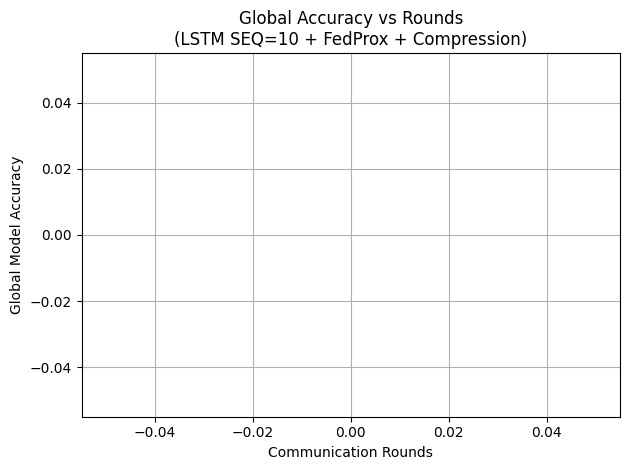

In [ ]:
plt.figure()
plt.plot(rounds, global_accuracies, marker='o', color='steelblue')
plt.xlabel("Communication Rounds")
plt.ylabel("Global Model Accuracy")
plt.title("Global Accuracy vs Rounds\n(LSTM SEQ=10 + FedProx + Compression)")
plt.grid(True)
plt.tight_layout()
plt.show()


Local Client Loss vs Training steps

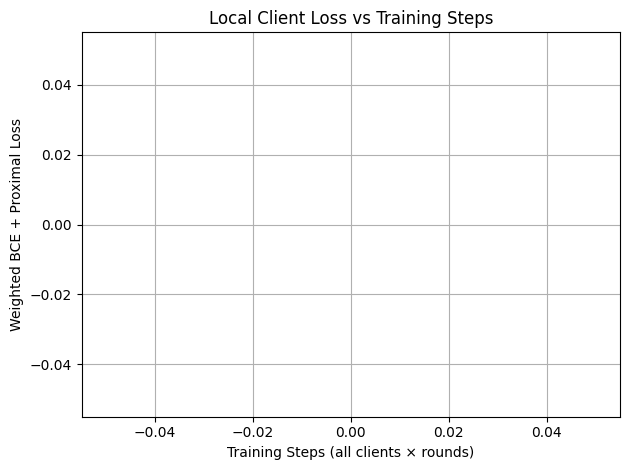

In [ ]:
plt.figure()
plt.plot(range(1, len(local_losses)+1), local_losses,
         marker='x', color='orange')
plt.xlabel("Training Steps (all clients × rounds)")
plt.ylabel("Weighted BCE + Proximal Loss")
plt.title("Local Client Loss vs Training Steps")
plt.grid(True)
plt.tight_layout()
plt.show()

ROC Curve

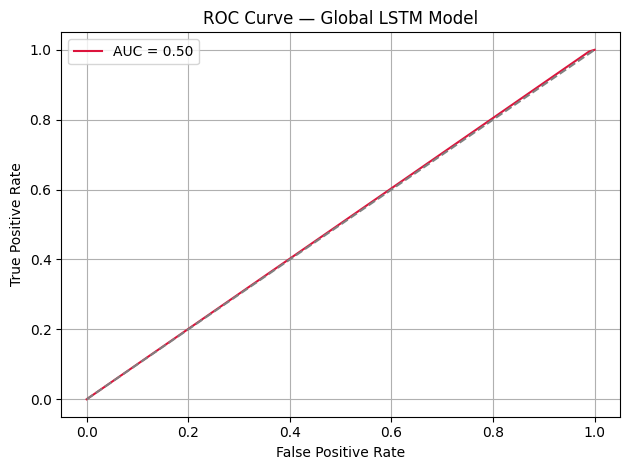

In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='crimson', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Global LSTM Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Precision-Recall Curve

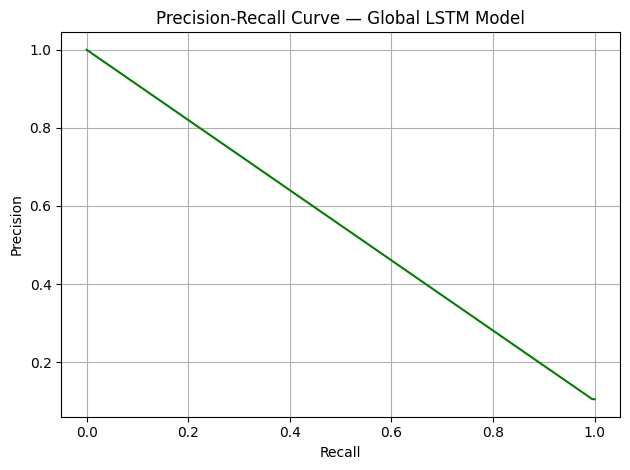

In [ ]:
plt.figure()
plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Global LSTM Model")
plt.grid(True)
plt.tight_layout()
plt.show()


Model Gain per Round

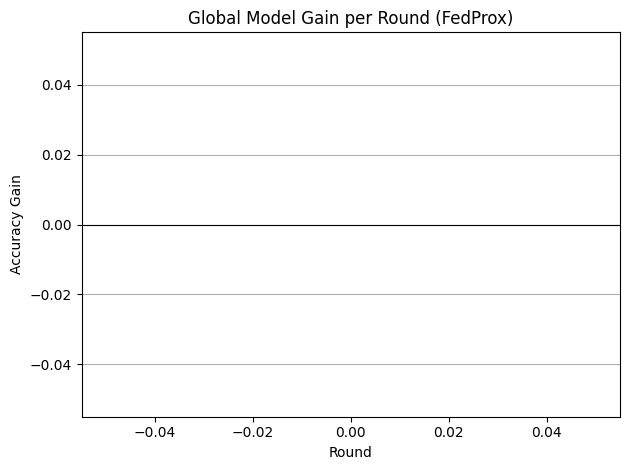

In [ ]:
model_gain = [global_accuracies[i] - global_accuracies[i-1]
              for i in range(1, len(global_accuracies))]
plt.figure()
plt.bar(range(1, len(model_gain)+1), model_gain, color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel("Round")
plt.ylabel("Accuracy Gain")
plt.title("Global Model Gain per Round (FedProx)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

RASC Tier Distribution & Compredata)ssion Ratio (from real training

In [ ]:
"""RASC Tier Distribution & Compredata)ssion Ratio (from real training """

# Bit-width each tier actually sends, per RASC_LEVELS (see compress()):
#   critical  -> 256 levels ~ 16-bit
#   important -> 128 levels ~  8-bit
#   minor     ->  16 levels ~  4-bit
#   discard   ->   0 levels ~  0-bit (dropped, only error-fed back)
TIER_ORDER = ['critical', 'important', 'minor', 'discard']
TIER_BITS  = {'critical': 16, 'important': 8, 'minor': 4, 'discard': 0}
TIER_LABELS = {
    'critical' : 'Critical\n(16-bit)',
    'important': 'Important\n(8-bit)',
    'minor'    : 'Minor\n(4-bit)',
    'discard'  : 'Discard\n(0-bit)',
}

tier_elements = {t: 0 for t in TIER_ORDER}
for entry in rasc_tier_log:
    tier_elements[entry['tier']] += entry['elements']

total_elements = sum(tier_elements.values())

if total_elements > 0:
    tier_pct = {t: tier_elements[t] / total_elements * 100 for t in TIER_ORDER}
    # Overall achieved payload size relative to sending everything at float32 (32-bit)
    overall_payload_pct = sum(
        tier_elements[t] * TIER_BITS[t] for t in TIER_ORDER
    ) / (total_elements * 32) * 100

    labels = [TIER_LABELS[t] for t in TIER_ORDER]
    sizes  = [tier_pct[t] for t in TIER_ORDER]
    colors = ['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f']

    plt.figure(figsize=(8, 4))
    bars = plt.bar(labels, sizes, color=colors, edgecolor='black', width=0.5)
    for bar, pct in zip(bars, sizes):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
    plt.ylabel("Share of Parameters Assigned to Tier (%)")
    plt.title(f"RASC Tier Distribution Across Training\n"
              f"(Overall payload size: {overall_payload_pct:.1f}% of original float32)")
    plt.ylim(0, max(sizes) + 15)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No RASC tier data logged — compress() was not called, "
          "skipping tier distribution plot.")

⚠️  No RASC tier data logged — compress() was not called, skipping tier distribution plot.


Local Distribution

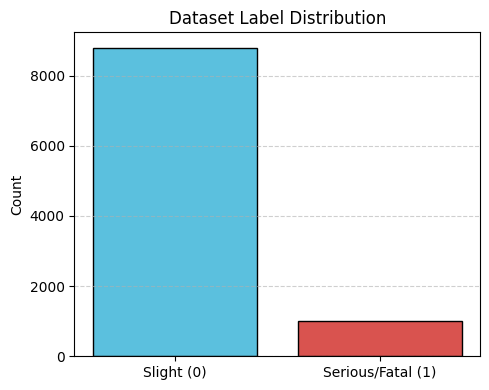

In [ ]:
plt.figure(figsize=(5, 4))
counts = pd.Series(y_seq).value_counts().sort_index()
plt.bar(['Slight (0)', 'Serious/Fatal (1)'],
        counts.values, color=['#5bc0de', '#d9534f'], edgecolor='black')
plt.ylabel("Count")
plt.title("Dataset Label Distribution")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()